# Критерії випадковості та сезонності часових рядів

In [3]:
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional

import numpy as np
import polars as pl
from scipy.stats import binomtest, linregress, norm
from statsmodels.graphics.tsaplots import plot_acf

In [40]:
@dataclass
class TimeSeries:
    file_path: str
    series_col_name: str
    time_col_name: str
    time_format: str
    dataset: Optional[pl.DataFrame] = None

    def __post_init__(self):
        self.dataset = self._load_time_series()

    @property
    def series(self) -> pl.Series:
        return self.dataset[self.series_col_name]

    @property
    def times(self) -> pl.Series:
        return self.dataset[self.time_col_name]

    def _load_time_series(self) -> pl.DataFrame:
        if self.file_path.endswith('.csv'):
            return (
                pl.read_csv(self.file_path, try_parse_dates=True)
                .with_columns(pl.col(self.time_col_name).str.to_datetime(self.time_format))
                .sort(self.time_col_name)
            )
        raise TypeError(f"Unexpected file format: {self.file_path.split('.')[-1]}.")

    def plot_series(self) -> None:
        plt.plot(self.times, self.series)
        plt.xlabel("Times")
        plt.ylabel("Series")
        plt.grid(True)
        plt.show()

    def plot_acf(self, lags: int = 30) -> None:
        plot_acf(self.series, lags=lags)
        plt.title("Корелограма")
        plt.show()

    def sign_test(self, series: Optional[pl.Series] = None, probability_of_success: float = 0.5, alternative: str = 'two-sided') -> float:
        if series is None:
            series = self.series

        median = np.median(series)
        signs = series > median
        return binomtest(sum(signs), len(signs), probability_of_success, alternative=alternative).pvalue

    def record_test(self) -> float:
        records = [self.series[0]]
        record_count = 1
        for i in range(1, len(self.series)):
            if self.series[i] > max(records):
                record_count += 1
                records.append(self.series[i])
        expected = np.sum([1 / (i + 1) for i in range(len(self.series))])
        std = np.sqrt(np.sum([(1 / (i + 1)) * (1 - 1 / (i + 1)) for i in range(len(self.series))]))
        z = (record_count - expected) / std
        return 2 * (1 - norm.cdf(abs(z)))

    def remove_linear_trend(self, with_plot: bool = True) -> np.ndarray:
        y = self.series.to_numpy()
        x = np.arange(len(y))
        slope, intercept, *_ = linregress(x, y)
        trend = intercept + slope * x
        residuals = y - trend
        if with_plot:
            plt.plot(residuals)
            plt.title("Залишки після видалення тренду")
            plt.grid(True)
            plt.show()
        return residuals

In [42]:
# time_series = TimeSeries(
#     file_path='./data/AirPassengers.csv',
#     series_col_name='Passengers',
#     time_col_name='Month',
#     time_format='%Y-%m'
# )
time_series = TimeSeries(
    file_path='./data/MLTollsStackOverflow.csv',
    series_col_name='python',
    time_col_name='month',
    time_format='%y-%b'
)
time_series.dataset

month,python,scipy,matlab,machine-learning,pandas,r,pytorch,keras,nlp,apache-spark,hadoop,pyspark,python-3.x,tensorflow,deep-learning,neural-network,lstm,time-series,pillow,rasa,opencv,pipenv,seaborn,Dask,jupyter,AllenNLP,Theano,plotly,scikit-learn,BeautifulSoup,scrapy,Gensim,FastText,Pydot,Pybrain,Pytil,Pygame,Colab,Shogun,KNIME,Apache,Gunicorn,Pygtk,Weka,Conda,Ray,matlab_duplicated_0,accord.net,regression,classification,correlation,cluster-analysis,H2o,Mallet,Trifacta,PyArrow,Rasterio,Orange3,PyMC3,Oryx,Istio,Venes,Plotnine,Gluon,Plato,Sympy,Flair,stanford-nlp,pyqt,Nolearn,Lasagne,OCR,Apache-spark-mlib,azure-virtual-machine
datetime[μs],i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
2009-01-01 00:00:00,631,2,19,8,0,8,0,0,8,0,1,0,4,0,0,4,0,1,0,0,3,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,95,0,3,0,0,0,19,0,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,5,0,0,5,0,0
2009-02-01 00:00:00,633,3,27,4,0,9,0,0,9,0,1,0,12,0,0,4,0,2,0,0,1,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,4,0,0,0,114,0,7,0,0,0,27,0,3,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,11,0,0
2009-03-01 00:00:00,766,2,24,3,0,4,0,0,12,0,1,0,4,0,0,11,0,1,0,0,7,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,7,0,0,0,104,0,6,0,0,0,24,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,0,0,2,0,0
2009-04-01 00:00:00,768,3,32,10,0,12,0,0,14,0,6,0,10,0,0,6,0,0,0,0,8,0,0,0,0,0,0,0,0,3,0,0,0,0,0,1,6,0,0,0,111,0,3,0,0,0,32,0,0,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,5,0,0
2009-05-01 00:00:00,1003,2,42,7,0,2,0,0,9,0,3,0,19,0,0,7,0,0,0,0,10,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,2,0,0,0,127,0,5,0,0,0,42,0,2,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,0,0,3,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2019-08-01 00:00:00,20257,212,371,583,3675,4486,253,889,237,922,216,0,6133,1332,373,191,112,141,0,19,605,31,119,66,104,0,7,137,323,322,205,30,6,2,0,0,137,91,2,5,388,38,2,3,91,12,325,3,60,62,22,47,24,0,1,20,3,2,6,0,56,0,4,10,0,33,0,22,144,0,0,40,16,25
2019-09-01 00:00:00,19207,135,362,538,3298,4474,260,786,207,913,207,0,5748,1217,334,211,93,156,0,25,556,24,90,73,107,1,9,139,324,330,146,30,14,2,1,0,137,103,0,3,435,51,5,15,103,12,362,1,76,55,35,50,39,5,1,25,6,5,7,0,65,0,4,6,0,39,0,15,147,0,4,49,28,16
2019-10-01 00:00:00,23414,188,523,750,4098,5138,300,929,272,1075,260,0,6621,1468,451,265,131,203,0,16,648,36,130,73,132,0,19,174,415,350,165,27,15,1,0,0,180,120,1,4,402,55,3,12,120,18,522,4,125,81,37,65,23,2,0,19,7,9,3,0,49,0,5,6,0,72,0,27,170,0,3,70,21,19


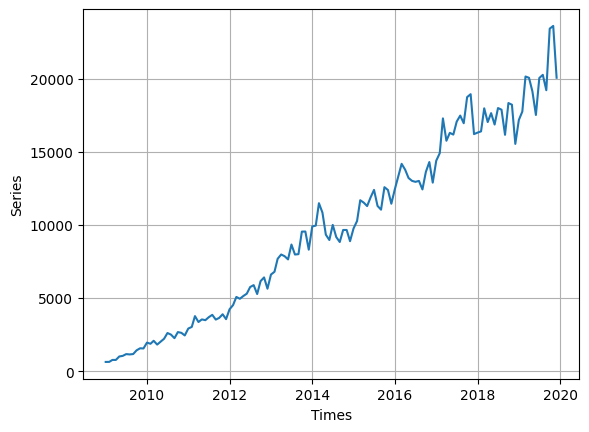

In [43]:
time_series.plot_series()

In [44]:
pv = time_series.sign_test()
print(f"Метод знаків: p-value = {pv:.3f}")

Метод знаків: p-value = 1.000


In [45]:
pv = time_series.record_test()
print(f"Метод рекордних значень: p-value = {pv}")

Метод рекордних значень: p-value = 0.0


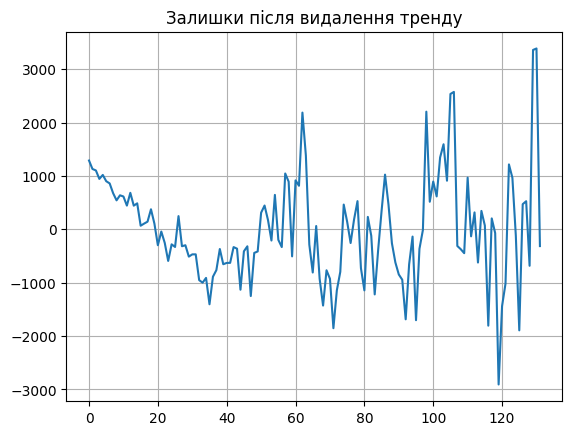

Метод знаків: p-value = 1.000


In [52]:
residuals = time_series.remove_linear_trend()
print(f"Метод знаків: p-value = {time_series.sign_test(residuals):.3f}")

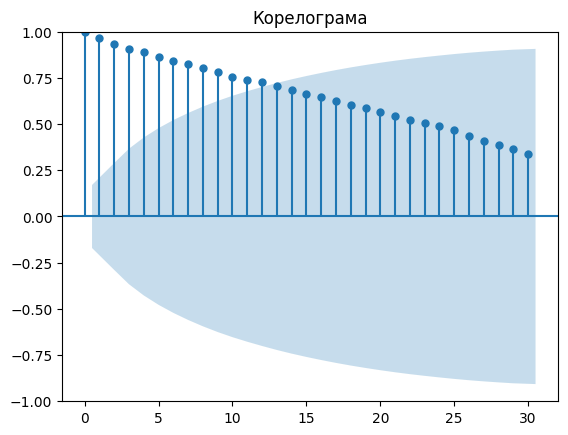

In [51]:
time_series.plot_acf()